# EEG Oddball Visualization

**Mục tiêu:** Tạo các biểu đồ rõ ràng, có ý nghĩa để đưa vào báo cáo.

**Công việc chính:**
- ⭐️ Biểu đồ ERP (Event-Related Potential) tại kênh Pz - so sánh Target vs Standard
- Biểu đồ thanh so sánh accuracy giữa các subjects
- **Nâng cao:** So sánh Band Power vs HMM Features

**Dữ liệu:**
- `processed_data.pkl`: MNE Epochs (raw time-series)
- `data/eeg.csv`: Band Power features
- `data/hmm.csv`: HMM features
- `results/model_performance_summary.csv`: Model results

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100, 'savefig.dpi': 300})

BLUE, ORANGE, GREEN, PURPLE = '#4472C4', '#ED7D31', '#70AD47', '#9B59B6'

# Load data
eeg_df = pd.read_csv('../data/eeg.csv')
hmm_df = pd.read_csv('../data/hmm.csv')
results_df = pd.read_csv('../results/model_performance_summary.csv')

try:
    with open('../processed/processed_data.pkl', 'rb') as f:
        processed_data = pickle.load(f)
    
    # processed_data là dict {subject_id: epochs}
    # Concatenate tất cả subjects thành 1 Epochs object
    from mne import concatenate_epochs
    epochs_list = list(processed_data.values())
    epochs = concatenate_epochs(epochs_list)
    
    print(f"✓ Loaded {len(processed_data)} subjects")
    print(f"✓ Total epochs: {len(epochs)}")
    print(f"✓ Event IDs: {epochs.event_id}")
except:
    epochs = None
    print("⚠️ Could not load processed_data.pkl")

Not setting metadata
1005 matching events found
Applying baseline correction (mode: mean)
✓ Loaded 5 subjects
✓ Total epochs: 1005
✓ Event IDs: {'Stimulus/S  5': 5, 'Stimulus/S  6': 6, 'Stimulus/S  7': 7}


In [22]:
def get_channel_index(epochs, channel_name):
    """Get channel index, with fallback"""
    ch_names = epochs.ch_names
    if channel_name in ch_names:
        return ch_names.index(channel_name), channel_name
    similar = [ch for ch in ch_names if channel_name.lower() in ch.lower()]
    if similar:
        return ch_names.index(similar[0]), similar[0]
    return None, None

def get_epochs_by_event(epochs, event_name):
    """Get epochs by event name with flexible matching"""
    event_map = {
        'target': ['Stimulus/S  6', 'target', '6'],
        'standard': ['Stimulus/S  5', 'frequent', '5']
    }
    
    for name in event_map.get(event_name, []):
        if name in epochs.event_id:
            return epochs[name]
    
    raise KeyError(f"Event '{event_name}' not found in {list(epochs.event_id.keys())}")

In [23]:
def get_epochs_by_event(epochs, event_name):
    """Get epochs by event name with fallback."""
    event_map = {
        'target': ['Stimulus/S  6', 'target', '6'],
        'standard': ['Stimulus/S  5', 'frequent', '5']
    }
    
    for name in event_map.get(event_name, []):
        if name in epochs.event_id:
            return epochs[name]
    
    raise KeyError(f"Event '{event_name}' not found in {list(epochs.event_id.keys())}")


def get_channel_index(epochs, channel='Pz'):
    """Get channel index with fallback."""
    for ch in [channel, channel.upper(), 'Cz', 'CZ']:
        if ch in epochs.ch_names:
            return epochs.ch_names.index(ch), ch
    return 0, epochs.ch_names[0]

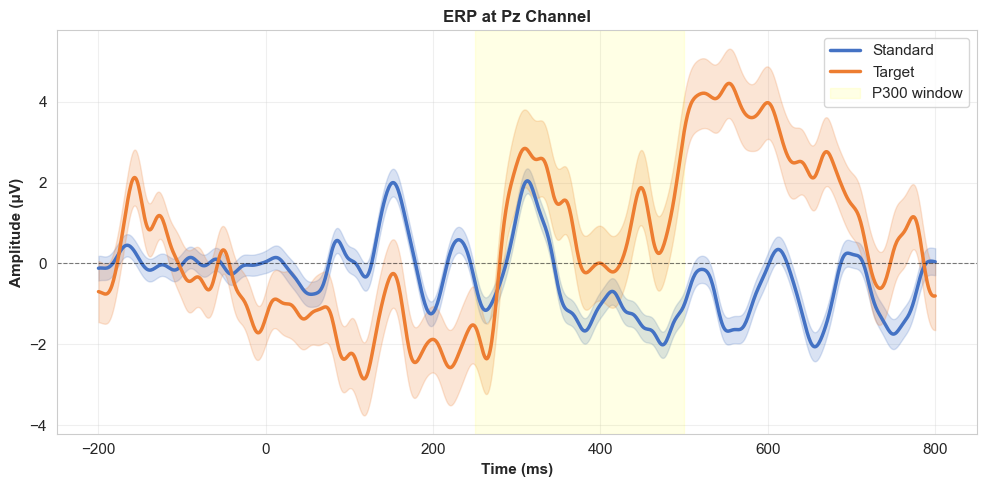

In [24]:
if epochs is None:
    print("⚠️ Skipping ERP plot - no processed_data")
else:
    # Extract data
    target_epochs = get_epochs_by_event(epochs, 'target')
    standard_epochs = get_epochs_by_event(epochs, 'standard')
    
    pz_idx, ch_name = get_channel_index(epochs, 'Pz')
    target_data = target_epochs.get_data()[:, pz_idx, :] * 1e6
    standard_data = standard_epochs.get_data()[:, pz_idx, :] * 1e6
    times = epochs.times * 1000
    
    # Calculate means
    target_mean = target_data.mean(0)
    target_sem = stats.sem(target_data, 0)
    standard_mean = standard_data.mean(0)
    standard_sem = stats.sem(standard_data, 0)
    
    # Plot ERP Comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(times, standard_mean, label='Standard', color=BLUE, lw=2.5)
    ax.fill_between(times, standard_mean-standard_sem, standard_mean+standard_sem, 
                     alpha=0.2, color=BLUE)
    ax.plot(times, target_mean, label='Target', color=ORANGE, lw=2.5)
    ax.fill_between(times, target_mean-target_sem, target_mean+target_sem, 
                     alpha=0.2, color=ORANGE)
    ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axvspan(250, 500, alpha=0.1, color='yellow', label='P300 window')
    ax.set_xlabel('Time (ms)', fontweight='bold')
    ax.set_ylabel('Amplitude (μV)', fontweight='bold')
    ax.set_title(f'ERP at {ch_name} Channel', fontweight='bold', fontsize=12)
    ax.legend(frameon=True)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

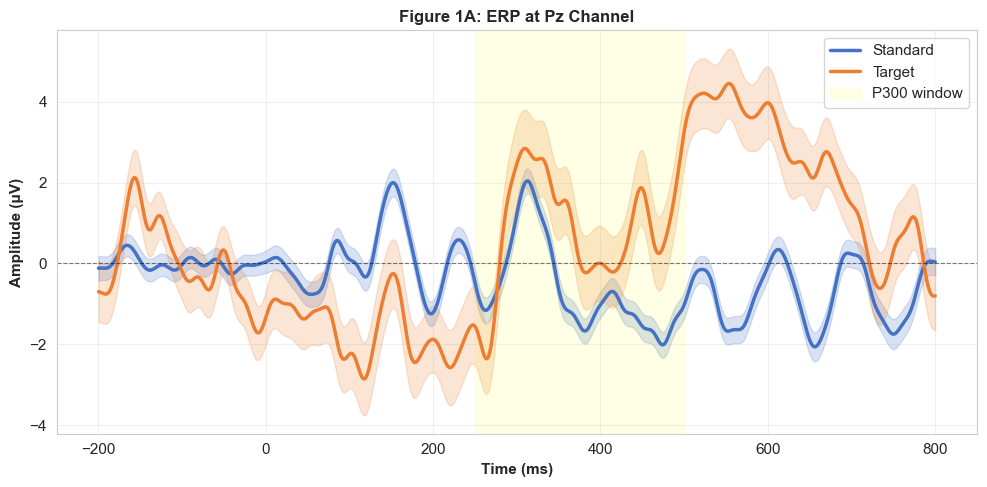

In [25]:
if epochs is None:
    print("⚠️ Skipping ERP plot - no processed_data")
else:
    # Extract data
    target_epochs = get_epochs_by_event(epochs, 'target')
    standard_epochs = get_epochs_by_event(epochs, 'standard')
    
    pz_idx, ch_name = get_channel_index(epochs, 'Pz')
    target_data = target_epochs.get_data()[:, pz_idx, :] * 1e6
    standard_data = standard_epochs.get_data()[:, pz_idx, :] * 1e6
    times = epochs.times * 1000
    
    # Calculate means
    target_mean = target_data.mean(0)
    target_sem = stats.sem(target_data, 0)
    standard_mean = standard_data.mean(0)
    standard_sem = stats.sem(standard_data, 0)
    
    # Plot ERP Comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(times, standard_mean, label='Standard', color=BLUE, lw=2.5)
    ax.fill_between(times, standard_mean-standard_sem, standard_mean+standard_sem, 
                     alpha=0.2, color=BLUE)
    ax.plot(times, target_mean, label='Target', color=ORANGE, lw=2.5)
    ax.fill_between(times, target_mean-target_sem, target_mean+target_sem, 
                     alpha=0.2, color=ORANGE)
    ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axvspan(250, 500, alpha=0.1, color='yellow', label='P300 window')
    ax.set_xlabel('Time (ms)', fontweight='bold')
    ax.set_ylabel('Amplitude (μV)', fontweight='bold')
    ax.set_title(f'Figure 1A: ERP at {ch_name} Channel', fontweight='bold', fontsize=12)
    ax.legend(frameon=True)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

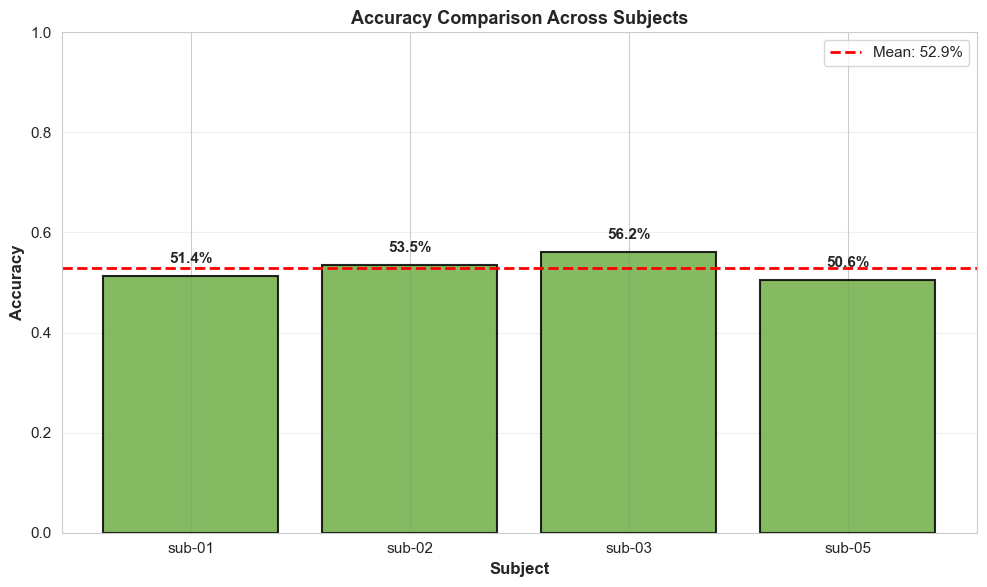

In [26]:
subjects = sorted(eeg_df['subject_id'].unique())
subject_accs = []

for subj in subjects:
    subj_data = eeg_df[eeg_df['subject_id'] == subj]
    threshold = subj_data['Peak_Amp'].median()
    predictions = (subj_data['Peak_Amp'] > threshold).astype(int)
    accuracy = (predictions == subj_data['label']).mean()
    subject_accs.append(accuracy)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(subjects)), subject_accs, color=GREEN, alpha=0.85, 
              edgecolor='k', lw=1.5)

for i, (bar, acc) in enumerate(zip(bars, subject_accs)):
    ax.text(i, acc+0.02, f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')

mean_acc = np.mean(subject_accs)
ax.axhline(mean_acc, color='r', ls='--', lw=2, label=f'Mean: {mean_acc:.1%}')

ax.set_xlabel('Subject', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Accuracy Comparison Across Subjects', fontweight='bold', fontsize=13)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects)
ax.set_ylim([0, 1])
ax.legend(frameon=True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

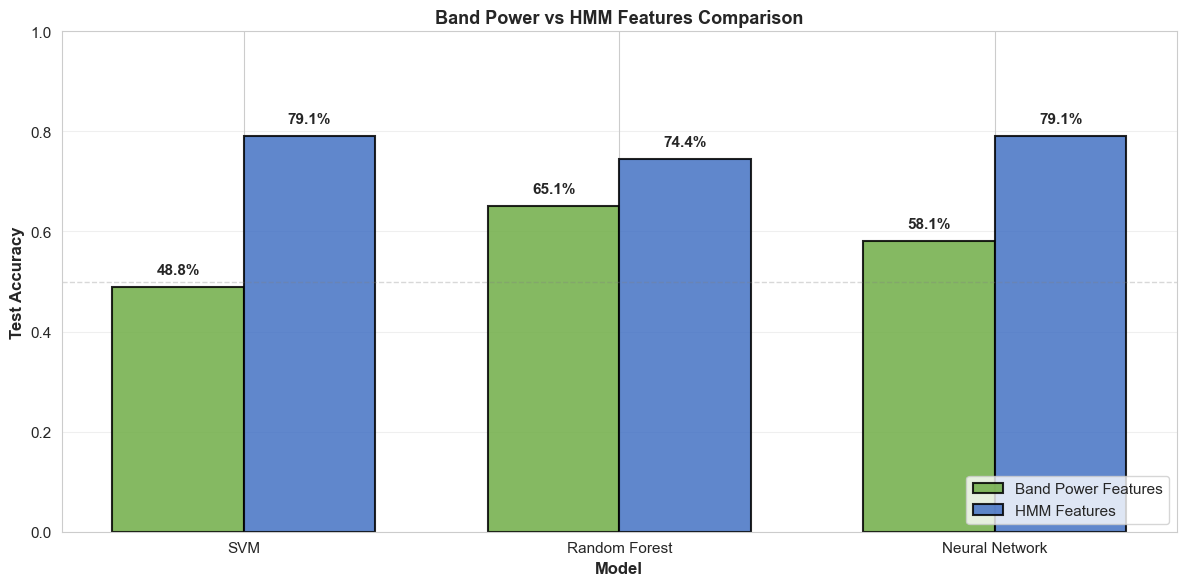

In [27]:
eeg_res = results_df[results_df['Feature'] == 'EEG']
hmm_res = results_df[results_df['Feature'] == 'HMM']
models = eeg_res['Model'].values
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, eeg_res['Test_Accuracy'].values, width, 
               label='Band Power Features', color=GREEN, alpha=0.85, edgecolor='k', lw=1.5)
bars2 = ax.bar(x + width/2, hmm_res['Test_Accuracy'].values, width, 
               label='HMM Features', color=BLUE, alpha=0.85, edgecolor='k', lw=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.1%}', 
                ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Band Power vs HMM Features Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0, 1])
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.3)
ax.legend(frameon=True, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()